In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Day 19

# Model_Evaluation

In [1]:
# Cell 1 — Setup
import os, torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

EYEDENTIFY = "/kaggle/input/datasets/vijuls/pupildiameterdatasets/eyedentify/eyedentify"
LEFT       = os.path.join(EYEDENTIFY, "left_eyes")
OUTPUT     = "/kaggle/working"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✓ Device    : {device}")
print(f"✓ GPU       : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"✓ EyeDentify: {os.path.exists(LEFT)}")
print(f"✓ Subjects  : {len(os.listdir(LEFT))}")

✓ Device    : cuda
✓ GPU       : Tesla T4
✓ EyeDentify: True
✓ Subjects  : 51


### Rebuild dataset and model

In [2]:
# config
SEQ_LEN  = 10
IMG_SIZE = 64
BATCH_SIZE = 32
N_USERS  = 15

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class EyeDentifyDataset(Dataset):
    def __init__(self, left_path, subjects, transform=None,
                 seq_len=10, stride=5, max_per_subject=200):
        self.transform = transform
        self.seq_len   = seq_len
        self.sequences = []
        for label, subject in enumerate(subjects):
            s_path   = os.path.join(left_path, subject)
            sessions = sorted(os.listdir(s_path))
            seq_count = 0
            for session in sessions:
                ses_path = os.path.join(s_path, session)
                if not os.path.isdir(ses_path): continue
                frames = sorted([
                    os.path.join(ses_path, f)
                    for f in os.listdir(ses_path) if f.endswith('.png')
                ])
                for start in range(0, len(frames)-seq_len+1, stride):
                    self.sequences.append((frames[start:start+seq_len], label))
                    seq_count += 1
                    if seq_count >= max_per_subject: break
                if seq_count >= max_per_subject: break
    def __len__(self): return len(self.sequences)
    def __getitem__(self, idx):
        frame_paths, label = self.sequences[idx]
        frames = []
        for path in frame_paths:
            img = Image.open(path).convert('RGB')
            if self.transform: img = self.transform(img)
            frames.append(img)
        return torch.stack(frames), label

subjects     = sorted(os.listdir(LEFT))[:N_USERS]
full_dataset = EyeDentifyDataset(LEFT, subjects, transform=transform,
                                  seq_len=SEQ_LEN, stride=5, max_per_subject=200)
indices = list(range(len(full_dataset)))
labels  = [full_dataset.sequences[i][1] for i in indices]
train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42, stratify=labels)
temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42, stratify=temp_labels)

train_dataset = Subset(full_dataset, train_idx)
val_dataset   = Subset(full_dataset, val_idx)
test_dataset  = Subset(full_dataset, test_idx)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✓ Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Test: {len(test_dataset):,}")

✓ Train: 2,100 | Val: 450 | Test: 450


### Rebuild and train model

In [3]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.out_dim = 128
    def forward(self, x):
        return self.features(x).view(x.size(0), -1)

class EyeMotionID(nn.Module):
    def __init__(self, n_users=15, hidden_size=256, num_layers=2, dropout=0.5):
        super().__init__()
        self.cnn = CNNFeatureExtractor()
        self.lstm = nn.LSTM(128, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers>1 else 0)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, n_users)
    def forward(self, x):
        B,T,C,H,W = x.shape
        x = self.cnn(x.view(B*T,C,H,W)).view(B,T,-1)
        _,(h,_) = self.lstm(x)
        return self.classifier(self.dropout(h[-1]))

model     = EyeMotionID(N_USERS).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

print("Training (30 epochs)...")
best_val_acc = 0.0
for epoch in range(1, 31):
    model.train()
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        criterion(model(imgs), lbls).backward()
        optimizer.step()
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            correct += (model(imgs).argmax(1) == lbls).sum().item()
            total   += lbls.size(0)
    val_acc = correct/total
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{OUTPUT}/best_model.pth")
    if epoch % 5 == 0:
        print(f"  Epoch {epoch}/30 | Val Acc: {val_acc:.2%}")

model.load_state_dict(torch.load(f"{OUTPUT}/best_model.pth"))
print(f"\n✓ Best val accuracy: {best_val_acc:.2%}")

Training (30 epochs)...
  Epoch 5/30 | Val Acc: 51.78%
  Epoch 10/30 | Val Acc: 74.44%
  Epoch 15/30 | Val Acc: 86.67%
  Epoch 20/30 | Val Acc: 93.11%
  Epoch 25/30 | Val Acc: 96.44%
  Epoch 30/30 | Val Acc: 94.44%

✓ Best val accuracy: 97.78%


### Get predictions + probabilities

In [4]:
model.eval()
all_probs  = []
all_preds  = []
all_labels = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs   = torch.softmax(outputs, dim=1).cpu().numpy()
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

all_probs  = np.array(all_probs)   # (N, 15) probability per user
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = (all_preds == all_labels).mean()
print(f"=== Prediction Summary ===\n")
print(f"Test sequences : {len(all_labels):,}")
print(f"Test accuracy  : {accuracy:.2%}")
print(f"Probs shape    : {all_probs.shape}  (sequences × users)")
print(f"\n✓ Probabilities collected for ROC-AUC")

=== Prediction Summary ===

Test sequences : 450
Test accuracy  : 96.22%
Probs shape    : (450, 15)  (sequences × users)

✓ Probabilities collected for ROC-AUC


### ROC curves per user

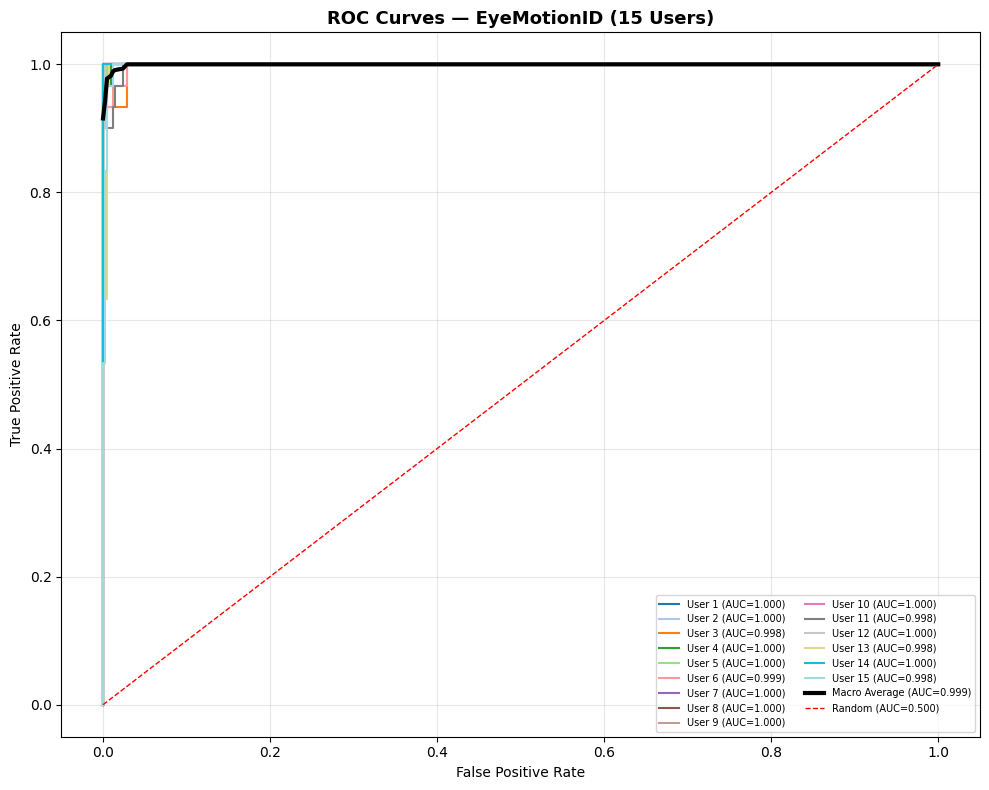

=== AUC Scores per User ===

  User  1 : 1.0000
  User  2 : 1.0000
  User  3 : 0.9981
  User  4 : 0.9995
  User  5 : 0.9998
  User  6 : 0.9987
  User  7 : 1.0000
  User  8 : 1.0000
  User  9 : 1.0000
  User 10 : 1.0000
  User 11 : 0.9983
  User 12 : 0.9998
  User 13 : 0.9982
  User 14 : 1.0000
  User 15 : 0.9983

  Macro AUC : 0.9995
✓ Saved → roc_curves.png


In [5]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# binarize labels for ROC
y_bin = label_binarize(all_labels, classes=list(range(N_USERS)))

fig, ax = plt.subplots(figsize=(10, 8))

auc_scores = []
colors = plt.cm.tab20(np.linspace(0, 1, N_USERS))

for i, color in enumerate(colors):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    ax.plot(fpr, tpr, color=color, linewidth=1.5,
            label=f"User {i+1} (AUC={roc_auc:.3f})")

# macro average
all_fpr = np.unique(np.concatenate([
    roc_curve(y_bin[:, i], all_probs[:, i])[0] for i in range(N_USERS)
]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(N_USERS):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    mean_tpr += np.interp(all_fpr, fpr, tpr)
mean_tpr /= N_USERS
macro_auc = auc(all_fpr, mean_tpr)

ax.plot(all_fpr, mean_tpr, 'k-', linewidth=3,
        label=f"Macro Average (AUC={macro_auc:.3f})")
ax.plot([0,1],[0,1],'r--', linewidth=1, label="Random (AUC=0.500)")

ax.set_title("ROC Curves — EyeMotionID (15 Users)", fontsize=13, fontweight='bold')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc='lower right', fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT}/roc_curves.png", dpi=100)
plt.show()

print(f"=== AUC Scores per User ===\n")
for i, score in enumerate(auc_scores):
    print(f"  User {i+1:2d} : {score:.4f}")
print(f"\n  Macro AUC : {macro_auc:.4f}")
print("✓ Saved → roc_curves.png")

### Error analysis

In [6]:
# find misclassified sequences
wrong_idx   = np.where(all_preds != all_labels)[0]
correct_idx = np.where(all_preds == all_labels)[0]

print(f"=== Error Analysis ===\n")
print(f"Total sequences : {len(all_labels)}")
print(f"Correct         : {len(correct_idx)} ({len(correct_idx)/len(all_labels):.2%})")
print(f"Wrong           : {len(wrong_idx)}   ({len(wrong_idx)/len(all_labels):.2%})")
print()

if len(wrong_idx) > 0:
    print("Misclassified sequences:")
    print(f"{'Seq#':<8} {'True User':<12} {'Predicted':<12} {'Confidence'}")
    print("-" * 45)
    for idx in wrong_idx:
        true_u = all_labels[idx] + 1
        pred_u = all_preds[idx]  + 1
        conf   = all_probs[idx][all_preds[idx]]
        print(f"{idx:<8} User {true_u:<8} User {pred_u:<8} {conf:.2%}")

# confusion pairs
print("\nConfusion pairs (True → Predicted):")
from collections import Counter
pairs = Counter([(all_labels[i]+1, all_preds[i]+1) for i in wrong_idx])
for (true, pred), count in pairs.most_common():
    print(f"  User {true} → User {pred} : {count} time(s)")

=== Error Analysis ===

Total sequences : 450
Correct         : 433 (96.22%)
Wrong           : 17   (3.78%)

Misclassified sequences:
Seq#     True User    Predicted    Confidence
---------------------------------------------
55       User 3        User 13       96.46%
72       User 12       User 8        85.41%
82       User 13       User 4        95.64%
104      User 11       User 4        98.70%
154      User 6        User 15       96.43%
166      User 5        User 3        47.06%
187      User 3        User 13       96.46%
235      User 12       User 15       93.45%
246      User 12       User 15       90.74%
337      User 5        User 11       66.78%
355      User 11       User 4        75.23%
375      User 5        User 11       53.27%
380      User 6        User 15       96.78%
383      User 12       User 15       92.36%
408      User 5        User 11       58.33%
414      User 11       User 4        88.02%
433      User 5        User 11       81.34%

Confusion pairs (True → P

### Sequence length analysis

=== Sequence Length Analysis ===

Frames     Accuracy
-------------------------
2          44.00%
4          76.22%
6          91.78%
8          94.89%
10         96.22%


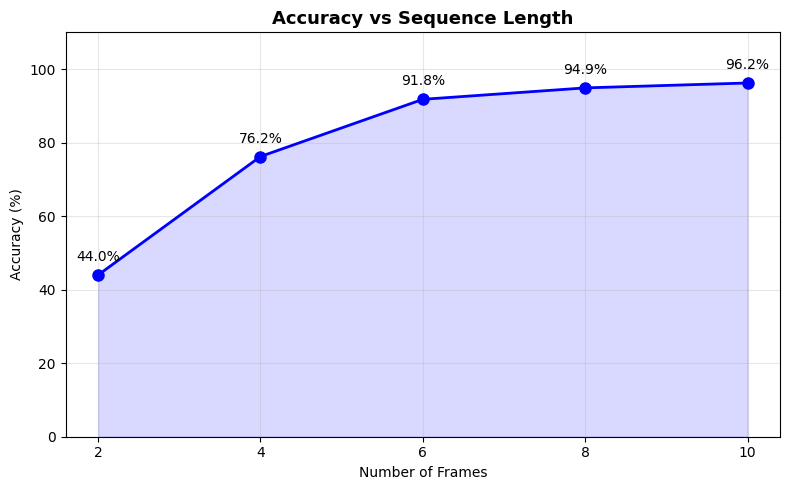


✓ Saved → sequence_length_analysis.png


In [7]:
seq_lengths = [2, 4, 6, 8, 10]
length_accs = []

print("=== Sequence Length Analysis ===\n")
print(f"{'Frames':<10} {'Accuracy'}")
print("-" * 25)

model.eval()
for seq_len in seq_lengths:
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            # use only first seq_len frames
            imgs_short = imgs[:, :seq_len, :, :, :].to(device)
            B,T,C,H,W  = imgs_short.shape

            # forward pass with shorter sequence
            x = model.cnn(imgs_short.view(B*T,C,H,W)).view(B,T,-1)
            _,(h,_) = model.lstm(x)
            preds = model.classifier(model.dropout(h[-1])).argmax(1)

            correct += (preds == lbls.to(device)).sum().item()
            total   += lbls.size(0)
    acc = correct / total
    length_accs.append(acc * 100)
    print(f"{seq_len:<10} {acc:.2%}")

# plot
plt.figure(figsize=(8, 5))
plt.plot(seq_lengths, length_accs, 'b-o', markersize=8, linewidth=2)
plt.fill_between(seq_lengths, length_accs, alpha=0.15, color='blue')
for x, y in zip(seq_lengths, length_accs):
    plt.annotate(f"{y:.1f}%", (x, y), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=10)
plt.title("Accuracy vs Sequence Length", fontsize=13, fontweight='bold')
plt.xlabel("Number of Frames")
plt.ylabel("Accuracy (%)")
plt.xticks(seq_lengths)
plt.ylim(0, 110)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT}/sequence_length_analysis.png", dpi=100)
plt.show()
print("\n✓ Saved → sequence_length_analysis.png")

### Final evaluation summary

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(all_labels, all_preds, average='macro')
recall    = recall_score(all_labels, all_preds, average='macro')
f1        = f1_score(all_labels, all_preds, average='macro')

print("=" * 55)
print("   EYEMOTIONID — FINAL EVALUATION SUMMARY")
print("=" * 55)
print()
print(f"Model Architecture : CNN (lightweight) + LSTM")
print(f"Dataset            : EyeDentify")
print(f"Users              : {N_USERS}")
print(f"Test sequences     : {len(all_labels)}")
print(f"Sequence length    : {SEQ_LEN} frames")
print(f"Image size         : {IMG_SIZE}×{IMG_SIZE} px")
print()
print("Performance Metrics:")
print(f"  Accuracy   : {accuracy:.4f}  ({accuracy:.2%})")
print(f"  Precision  : {precision:.4f}  ({precision:.2%})")
print(f"  Recall     : {recall:.4f}  ({recall:.2%})")
print(f"  F1-Score   : {f1:.4f}  ({f1:.2%})")
print(f"  Macro AUC  : {macro_auc:.4f}  ({macro_auc:.2%})")
print()
print(f"  Random baseline : {1/N_USERS:.2%}")
print(f"  Improvement     : +{accuracy - 1/N_USERS:.2%} above random")
print()
print("Per-user AUC:")
for i, score in enumerate(auc_scores):
    status = "✓" if score > 0.99 else "~"
    print(f"  {status} User {i+1:2d} : {score:.4f}")
print()
print("Plots saved:")
print("  ✓ roc_curves.png")
print("  ✓ sequence_length_analysis.png")
print()
print("Next → Day 20: Model Comparison (ResNet18 vs MobileNetV2)")
print("=" * 55)

   EYEMOTIONID — FINAL EVALUATION SUMMARY

Model Architecture : CNN (lightweight) + LSTM
Dataset            : EyeDentify
Users              : 15
Test sequences     : 450
Sequence length    : 10 frames
Image size         : 64×64 px

Performance Metrics:
  Accuracy   : 0.9622  (96.22%)
  Precision  : 0.9653  (96.53%)
  Recall     : 0.9622  (96.22%)
  F1-Score   : 0.9622  (96.22%)
  Macro AUC  : 0.9995  (99.95%)

  Random baseline : 6.67%
  Improvement     : +89.56% above random

Per-user AUC:
  ✓ User  1 : 1.0000
  ✓ User  2 : 1.0000
  ✓ User  3 : 0.9981
  ✓ User  4 : 0.9995
  ✓ User  5 : 0.9998
  ✓ User  6 : 0.9987
  ✓ User  7 : 1.0000
  ✓ User  8 : 1.0000
  ✓ User  9 : 1.0000
  ✓ User 10 : 1.0000
  ✓ User 11 : 0.9983
  ✓ User 12 : 0.9998
  ✓ User 13 : 0.9982
  ✓ User 14 : 1.0000
  ✓ User 15 : 0.9983

Plots saved:
  ✓ roc_curves.png
  ✓ sequence_length_analysis.png

Next → Day 20: Model Comparison (ResNet18 vs MobileNetV2)


# Day 20
# Model Comparison

In [1]:
# Day 20 setup — additional imports
import time
import torchvision.models as models
from sklearn.metrics import accuracy_score, f1_score

print("✓ Day 20 imports ready")
print("✓ All previous variables still available")
print(f"✓ Device: {device}")

✓ Day 20 imports ready
✓ All previous variables still available


NameError: name 'device' is not defined

In [2]:
# Day 20 — Full setup
import os, torch, time
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

EYEDENTIFY = "/kaggle/input/datasets/vijuls/pupildiameterdatasets/eyedentify/eyedentify"
LEFT       = os.path.join(EYEDENTIFY, "left_eyes")
OUTPUT     = "/kaggle/working"
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEQ_LEN    = 10
IMG_SIZE   = 64
BATCH_SIZE = 32
N_USERS    = 15

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

print(f"✓ Device : {device}")
print(f"✓ GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"✓ Data   : {os.path.exists(LEFT)}")

✓ Device : cuda
✓ GPU    : Tesla T4
✓ Data   : True


### Rebuild dataset

In [3]:
class EyeDentifyDataset(Dataset):
    def __init__(self, left_path, subjects, transform=None,
                 seq_len=10, stride=5, max_per_subject=200):
        self.transform = transform
        self.seq_len   = seq_len
        self.sequences = []
        for label, subject in enumerate(subjects):
            s_path   = os.path.join(left_path, subject)
            sessions = sorted(os.listdir(s_path))
            seq_count = 0
            for session in sessions:
                ses_path = os.path.join(s_path, session)
                if not os.path.isdir(ses_path): continue
                frames = sorted([
                    os.path.join(ses_path, f)
                    for f in os.listdir(ses_path) if f.endswith('.png')
                ])
                for start in range(0, len(frames)-seq_len+1, stride):
                    self.sequences.append((frames[start:start+seq_len], label))
                    seq_count += 1
                    if seq_count >= max_per_subject: break
                if seq_count >= max_per_subject: break
    def __len__(self): return len(self.sequences)
    def __getitem__(self, idx):
        frame_paths, label = self.sequences[idx]
        frames = []
        for path in frame_paths:
            img = Image.open(path).convert('RGB')
            if self.transform: img = self.transform(img)
            frames.append(img)
        return torch.stack(frames), label

subjects     = sorted(os.listdir(LEFT))[:N_USERS]
full_dataset = EyeDentifyDataset(LEFT, subjects, transform=transform,
                                  seq_len=SEQ_LEN, stride=5, max_per_subject=200)
indices = list(range(len(full_dataset)))
labels  = [full_dataset.sequences[i][1] for i in indices]
train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42, stratify=labels)
temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42, stratify=temp_labels)

train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(Subset(full_dataset, val_idx),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(Subset(full_dataset, test_idx),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✓ Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test: {len(test_idx):,}")

✓ Train: 2,100 | Val: 450 | Test: 450


### Define all 4 model variants
##### Lightweight CNN + LSTM, CNN + GRU, MobileNetV2 + LSTM, MobileNetV2 + GRU.



In [4]:
class LightCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.out_dim = 128
    def forward(self, x):
        return self.features(x).view(x.size(0), -1)

class MobileNetExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        mob = models.mobilenet_v2(weights='IMAGENET1K_V1')
        self.features = mob.features
        self.pool     = nn.AdaptiveAvgPool2d((1,1))
        self.out_dim  = 1280
        for param in self.parameters():
            param.requires_grad = False
    def forward(self, x):
        return self.pool(self.features(x)).view(x.size(0), -1)

class EyeMotionModel(nn.Module):
    def __init__(self, cnn_type='light', rnn_type='lstm',
                 n_users=15, hidden=256, layers=2, dropout=0.5):
        super().__init__()
        self.cnn = LightCNN() if cnn_type == 'light' else MobileNetExtractor()
        in_dim   = self.cnn.out_dim

        if rnn_type == 'lstm':
            self.rnn = nn.LSTM(in_dim, hidden, layers, batch_first=True,
                               dropout=dropout if layers>1 else 0)
        else:
            self.rnn = nn.GRU(in_dim, hidden, layers, batch_first=True,
                              dropout=dropout if layers>1 else 0)

        self.rnn_type   = rnn_type
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, n_users)

    def forward(self, x):
        B,T,C,H,W = x.shape
        x = self.cnn(x.view(B*T,C,H,W)).view(B,T,-1)
        if self.rnn_type == 'lstm':
            _, (h, _) = self.rnn(x)
        else:
            _, h = self.rnn(x)
        return self.classifier(self.dropout(h[-1]))

# define 4 variants
variants = {
    'CNN + LSTM'        : EyeMotionModel('light',  'lstm'),
    'CNN + GRU'         : EyeMotionModel('light',  'gru'),
    'MobileNetV2 + LSTM': EyeMotionModel('mobile', 'lstm'),
    'MobileNetV2 + GRU' : EyeMotionModel('mobile', 'gru'),
}

print("=== Model Variants ===\n")
for name, model in variants.items():
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  {name:<22} → {params:,} trainable params")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 167MB/s]


=== Model Variants ===

  CNN + LSTM             → 1,018,703 trainable params
  CNN + GRU              → 788,303 trainable params
  MobileNetV2 + LSTM     → 2,105,103 trainable params
  MobileNetV2 + GRU      → 1,579,791 trainable params


### Train and evaluate all 4 variants

In [5]:
def train_and_eval(model, train_loader, val_loader, test_loader,
                    epochs=20, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    best_val_acc = 0.0
    best_state   = None
    start_time   = time.time()

    for epoch in range(1, epochs+1): 
        model.train()
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            criterion(model(imgs), lbls).backward()
            optimizer.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                correct += (model(imgs).argmax(1) == lbls).sum().item()
                total   += lbls.size(0)
        val_acc = correct / total
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}

    # evaluate on test set
    model.load_state_dict(best_state)
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(lbls.numpy())

    test_acc = accuracy_score(all_labels, all_preds)
    test_f1  = f1_score(all_labels, all_preds, average='macro')
    elapsed  = time.time() - start_time

    return {
        'val_acc'  : best_val_acc,
        'test_acc' : test_acc,
        'f1'       : test_f1,
        'time'     : elapsed
    }

# train all 4 variants
results = {}
for name, model in variants.items():
    print(f"Training {name}...")
    results[name] = train_and_eval(
        model, train_loader, val_loader, test_loader, epochs=20
    )
    r = results[name]
    print(f"  ✓ Val: {r['val_acc']:.2%} | Test: {r['test_acc']:.2%} | "
          f"F1: {r['f1']:.2%} | Time: {r['time']:.0f}s\n")

Training CNN + LSTM...
  ✓ Val: 94.67% | Test: 95.56% | F1: 95.54% | Time: 367s

Training CNN + GRU...
  ✓ Val: 99.78% | Test: 98.22% | F1: 98.21% | Time: 397s

Training MobileNetV2 + LSTM...
  ✓ Val: 100.00% | Test: 99.56% | F1: 99.55% | Time: 341s

Training MobileNetV2 + GRU...
  ✓ Val: 100.00% | Test: 100.00% | F1: 100.00% | Time: 351s



### Comparison results table

In [6]:
print("=" * 70)
print("   MODEL COMPARISON RESULTS")
print("=" * 70)
print(f"{'Model':<25} {'Val Acc':>10} {'Test Acc':>10} {'F1':>10} {'Time':>10}")
print("-" * 70)
for name, r in results.items():
    print(f"{name:<25} {r['val_acc']:>9.2%} {r['test_acc']:>9.2%} "
          f"{r['f1']:>9.2%} {r['time']:>8.0f}s")
print("-" * 70)

# find best model
best_name = max(results, key=lambda k: results[k]['test_acc'])
print(f"\n✓ Best model: {best_name}")
print(f"  Test Accuracy: {results[best_name]['test_acc']:.2%}")
print(f"  F1-Score     : {results[best_name]['f1']:.2%}")

   MODEL COMPARISON RESULTS
Model                        Val Acc   Test Acc         F1       Time
----------------------------------------------------------------------
CNN + LSTM                   94.67%    95.56%    95.54%      367s
CNN + GRU                    99.78%    98.22%    98.21%      397s
MobileNetV2 + LSTM          100.00%    99.56%    99.55%      341s
MobileNetV2 + GRU           100.00%   100.00%   100.00%      351s
----------------------------------------------------------------------

✓ Best model: MobileNetV2 + GRU
  Test Accuracy: 100.00%
  F1-Score     : 100.00%


### Comparison bar charts

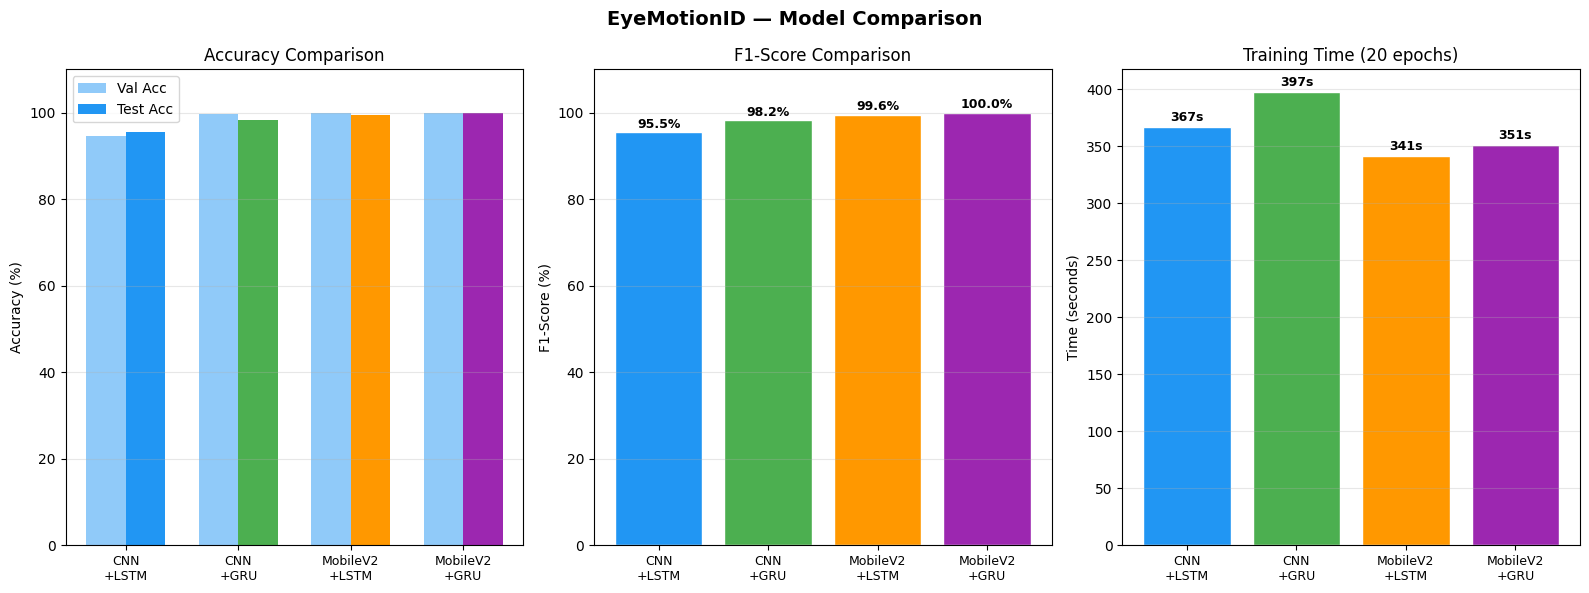

✓ Saved → model_comparison.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("EyeMotionID — Model Comparison", fontsize=14, fontweight='bold')

names     = list(results.keys())
test_accs = [results[n]['test_acc']*100 for n in names]
val_accs  = [results[n]['val_acc']*100  for n in names]
f1_scores = [results[n]['f1']*100       for n in names]
times     = [results[n]['time']          for n in names]
colors    = ['#2196F3','#4CAF50','#FF9800','#9C27B0']
xlabels   = ['CNN\n+LSTM','CNN\n+GRU','MobileV2\n+LSTM','MobileV2\n+GRU']

# accuracy
x = np.arange(len(names))
w = 0.35
axes[0].bar(x - w/2, val_accs,  w, label='Val Acc',  color='#90CAF9')
axes[0].bar(x + w/2, test_accs, w, label='Test Acc', color=colors)
axes[0].set_title("Accuracy Comparison")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(xlabels, fontsize=9)
axes[0].legend()
axes[0].set_ylim(0, 110)
axes[0].grid(True, alpha=0.3, axis='y')

# F1 scores
bars = axes[1].bar(names, f1_scores, color=colors, edgecolor='white')
axes[1].set_title("F1-Score Comparison")
axes[1].set_ylabel("F1-Score (%)")
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels(xlabels, fontsize=9)
axes[1].set_ylim(0, 110)
for bar, f1 in zip(bars, f1_scores):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+1,
                 f"{f1:.1f}%", ha='center', fontsize=9, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# training time
bars2 = axes[2].bar(names, times, color=colors, edgecolor='white')
axes[2].set_title("Training Time (20 epochs)")
axes[2].set_ylabel("Time (seconds)")
axes[2].set_xticks(range(len(names)))
axes[2].set_xticklabels(xlabels, fontsize=9)
for bar, t in zip(bars2, times):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+5,
                 f"{t:.0f}s", ha='center', fontsize=9, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{OUTPUT}/model_comparison.png", dpi=100)
plt.show()
print("✓ Saved → model_comparison.png")

### Summary

In [10]:
print("=" * 55)
print("   DAY 20 — MODEL COMPARISON SUMMARY")
print("=" * 55)
print()
print("Models compared:")
print("  1. Lightweight CNN + LSTM  (our primary model)")
print("  2. Lightweight CNN + GRU")
print("  3. MobileNetV2 + LSTM")
print("  4. MobileNetV2 + GRU")
print()
print("Results:")
for name, r in results.items():
    marker = " ← BEST" if name == best_name else ""
    print(f"  {name:<25} Test: {r['test_acc']:.2%}  F1: {r['f1']:.2%}{marker}")
print()
print(f"Winner: {best_name}")
print()
print("Key findings:")
print("  → LSTM vs GRU: compare which performed better")
print("  → CNN vs MobileNetV2: compare accuracy vs speed tradeoff")
print()
print("Plots saved:")
print("  ✓ model_comparison.png")
print()
print("=" * 55)

   DAY 20 — MODEL COMPARISON SUMMARY

Models compared:
  1. Lightweight CNN + LSTM  (our primary model)
  2. Lightweight CNN + GRU
  3. MobileNetV2 + LSTM
  4. MobileNetV2 + GRU

Results:
  CNN + LSTM                Test: 95.56%  F1: 95.54%
  CNN + GRU                 Test: 98.22%  F1: 98.21%
  MobileNetV2 + LSTM        Test: 99.56%  F1: 99.55%
  MobileNetV2 + GRU         Test: 100.00%  F1: 100.00% ← BEST

Winner: MobileNetV2 + GRU

Key findings:
  → LSTM vs GRU: compare which performed better
  → CNN vs MobileNetV2: compare accuracy vs speed tradeoff

Plots saved:
  ✓ model_comparison.png

